In [7]:
!git clone https://github.com/aliakseizvertouski/olist.git

fatal: destination path 'olist' already exists and is not an empty directory.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
customers = pd.read_csv('/content/olist/olist_customers_dataset.csv')
geo = pd.read_csv('/content/olist/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist/olist_sellers_dataset.csv')

# Информация о датасете

In [10]:
print (customers.columns)
print (geo.columns)
print (order_items.columns)
print (order_payments.columns)
print (order_reviews.columns)
print (orders.columns)
print (products.columns)
print (sellers.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['product_id', 'prod

# Соблюдение сроков доставки

In [11]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['estimated_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
delivered_orders['actual_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])


# Если дата доставки больше (позже) обещанной, там будет True, иначе False
delivered_orders['is_late'] = delivered_orders['actual_date'] > delivered_orders['estimated_date']

# 4. Считаем количество доставок вовремя и с опозданием
# False - вовремя, True - с опозданием
delivery_stats = delivered_orders['is_late'].value_counts()
delivery_stats.index = ['вовремя', 'опоздание'] # Переименуем для понятности

total_orders = len(delivered_orders)
late_percent = (delivery_stats['опоздание'] / total_orders) * 100

print(f"Всего доставлено заказов: {total_orders}")
print(delivery_stats)
print(f"Процент опозданий: {late_percent:.2f}%\n")

Всего доставлено заказов: 96478
вовремя      88652
опоздание     7826
Name: count, dtype: int64
Процент опозданий: 8.11%



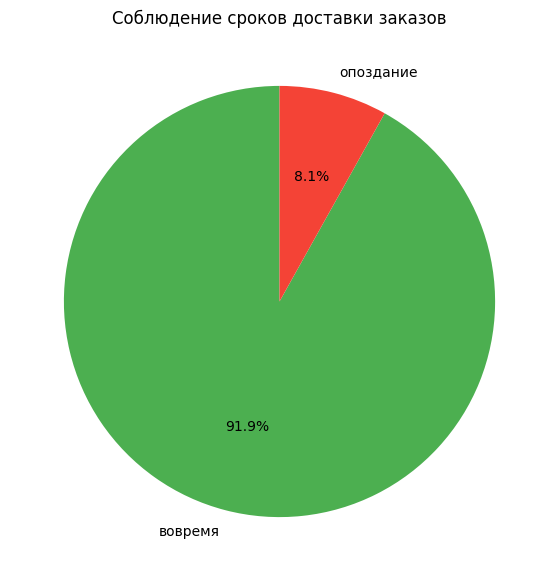

In [12]:
plt.figure(figsize=(7, 7))

plt.pie(
    delivery_stats,
    labels=delivery_stats.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)

plt.title('Соблюдение сроков доставки заказов')
plt.show()

## Самый долгий этап заказа

In [13]:
df = orders[orders['order_status'] == 'delivered'].copy()

# Список колонок, которые нужно превратить в даты
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

# Превращаем строки в даты
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# 2. Считаем время между этапами в днях
# Используем .dt.total_seconds() / 86400, чтобы получить дробное число дней (например, 1.5 дня)
df['days_to_approve'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['days_to_carrier'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / 86400
df['days_to_customer'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / 86400

# 3. Считаем среднее время для каждого этапа
mean_times = {
    '1. Подтверждение': df['days_to_approve'].mean(),
    '2. Сборка и склад': df['days_to_carrier'].mean(),
    '3. Доставка курьером': df['days_to_customer'].mean()
}

# Превращаем в Series для удобства построения графика
results = pd.Series(mean_times)

print("Среднее время этапов (в днях):")
print(results.round(2))

Среднее время этапов (в днях):
1. Подтверждение        0.43
2. Сборка и склад       2.80
3. Доставка курьером    9.33
dtype: float64


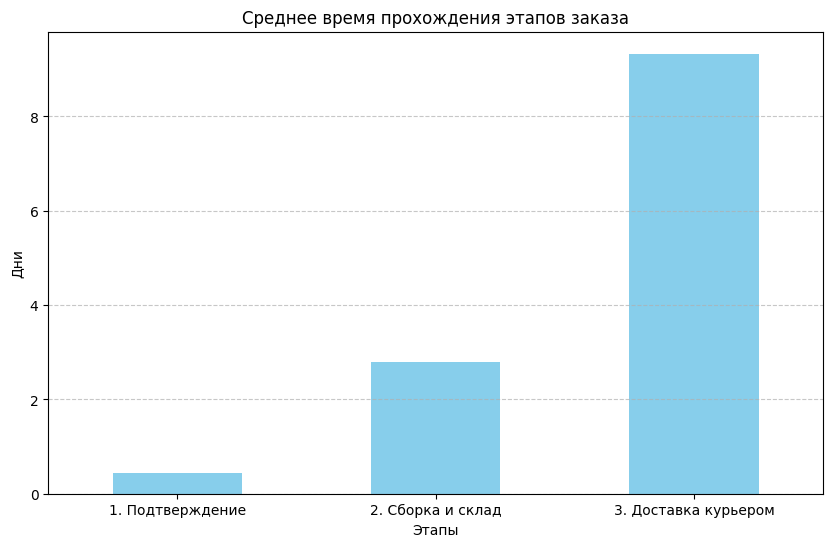

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
results.plot(kind='bar', color='skyblue')

plt.title('Среднее время прохождения этапов заказа')
plt.ylabel('Дни')
plt.xlabel('Этапы')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [15]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

df_geo = delivered_orders.merge(customers, on='customer_id')

df_geo['purchase'] = pd.to_datetime(df_geo['order_purchase_timestamp'])
df_geo['actual_delivery'] = pd.to_datetime(df_geo['order_delivered_customer_date'])
df_geo['estimated_delivery'] = pd.to_datetime(df_geo['order_estimated_delivery_date'])

df_geo['actual_days'] = (df_geo['actual_delivery'] - df_geo['purchase']).dt.total_seconds() / 86400
df_geo['estimated_days'] = (df_geo['estimated_delivery'] - df_geo['purchase']).dt.total_seconds() / 86400

state_stats = df_geo.groupby('customer_state')[['actual_days', 'estimated_days']].mean()

top_10_slowest = state_stats.sort_values(by='actual_days', ascending=False).head(10)

print("В какие штатты дольше всего доставляется товар?")
print(top_10_slowest.round(1))


В какие штатты дольше всего доставляется товар?
                actual_days  estimated_days
customer_state                             
RR                     29.4            46.0
AP                     27.2            46.2
AM                     26.4            45.3
AL                     24.5            32.6
PA                     23.8            37.2
MA                     21.6            30.5
SE                     21.5            30.8
CE                     21.3            31.4
AC                     21.0            41.1
PB                     20.4            33.0


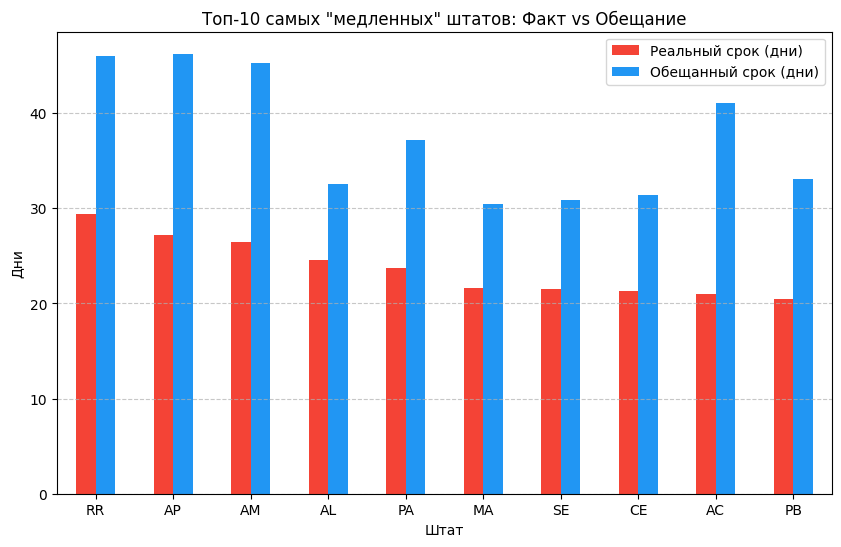

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
top_10_slowest.plot(kind='bar', ax=ax, color=['#f44336', '#2196f3'])

plt.title('Топ-10 самых "медленных" штатов: Факт vs Обещание')
plt.xlabel('Штат')
plt.ylabel('Дни')
plt.legend(['Реальный срок (дни)', 'Обещанный срок (дни)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Как часто опаздывают заказы? есть ли зависимость от штата доставки?

In [23]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
df_geo = delivered_orders.merge(customers, on='customer_id')

# Превращаем колонки в даты
df_geo['actual_delivery'] = pd.to_datetime(df_geo['order_delivered_customer_date'])
df_geo['estimated_delivery'] = pd.to_datetime(df_geo['order_estimated_delivery_date'])

# 2. Оставляем ТОЛЬКО опоздавшие заказы (где факт больше обещания)
late_orders = df_geo[df_geo['actual_delivery'] > df_geo['estimated_delivery']].copy()

# 3. Считаем "глубину" опоздания в днях
late_orders['delay_days'] = (late_orders['actual_delivery'] - late_orders['estimated_delivery']).dt.total_seconds() / 86400

# 4. Группируем по штатам: где опаздывают сильнее всего?
# Считаем среднее время задержки (mean) и количество таких задержек (count)
bad_states = late_orders.groupby('customer_state')['delay_days'].agg(['mean', 'count'])

# Отфильтруем штаты, где хотя бы больше 50 опоздавших заказов (чтобы исключить случайности)
bad_states = bad_states[bad_states['count'] > 50]

# Сортируем по среднему времени задержки и берем топ-10
top_10_delays = bad_states.sort_values(by='mean', ascending=False).head(10)

print("Топ-10 штатов по среднему времени опоздания:")
print(top_10_delays.round(1))

Топ-10 штатов по среднему времени опоздания:
                mean  count
customer_state             
SE              16.9     51
CE              14.3    196
RN              13.1     51
RJ              12.8   1664
PA              12.3    117
PI              12.3     76
PE              11.3    172
BA              11.1    457
ES              10.6    244
PB              10.5     57


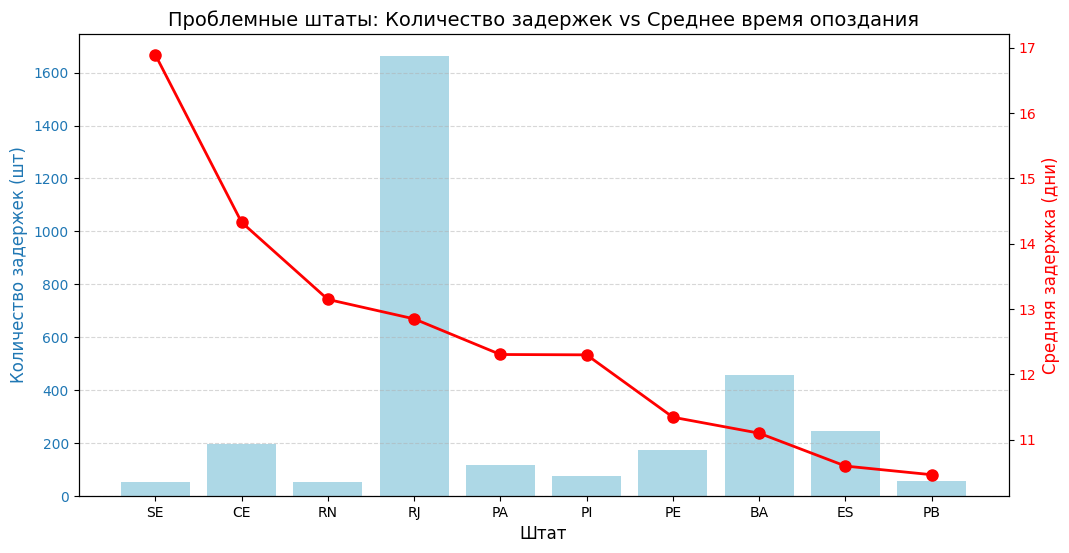

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(top_10_delays.index, top_10_delays['count'], color='lightblue')
ax1.set_xlabel('Штат', fontsize=12)
ax1.set_ylabel('Количество задержек (шт)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()

ax2.plot(top_10_delays.index, top_10_delays['mean'], color='red', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel('Средняя задержка (дни)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Проблемные штаты: Количество задержек vs Среднее время опоздания', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Отзывы покупателей

In [28]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
reviews_df = delivered_orders.merge(order_reviews, on='order_id')

# 2. Находим опоздавшие заказы
reviews_df['actual_date'] = pd.to_datetime(reviews_df['order_delivered_customer_date'])
reviews_df['estimated_date'] = pd.to_datetime(reviews_df['order_estimated_delivery_date'])

# Создаем колонку с понятным текстом вместо True/False
# Если факт больше обещания - 'С опозданием', иначе - 'Вовремя'
reviews_df['delivery_status'] = (reviews_df['actual_date'] > reviews_df['estimated_date']).map({True: 'С опозданием', False: 'Вовремя'})

# 3. Считаем среднюю оценку
mean_scores = reviews_df.groupby('delivery_status')['review_score'].mean()
print("Средняя оценка заказа:")
print(mean_scores.round(2))
print("-" * 30)

# 4. Считаем распределение оценок (в процентах)
# normalize='index' переводит штуки в доли от 0 до 1 по каждой строке. Умножаем на 100 для процентов.
score_distribution = pd.crosstab(reviews_df['delivery_status'], reviews_df['review_score'], normalize='index') * 100

print("Распределение оценок (в % от группы):")
print(score_distribution.round(1))

Средняя оценка заказа:
delivery_status
Вовремя         4.29
С опозданием    2.57
Name: review_score, dtype: float64
------------------------------
Распределение оценок (в % от группы):
review_score        1    2     3     4     5
delivery_status                             
Вовремя           6.6  2.6   8.0  20.3  62.4
С опозданием     46.2  7.9  11.4  12.4  22.2


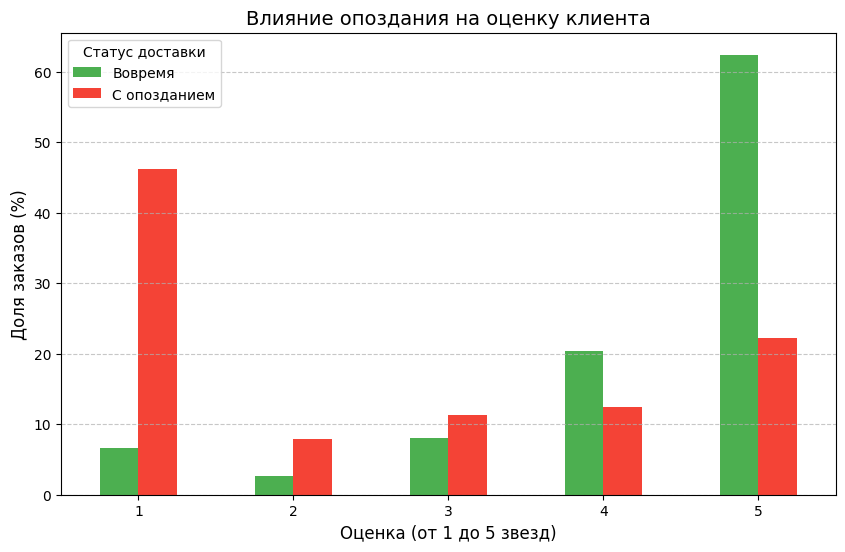

In [29]:
ax = score_distribution.T.plot(kind='bar', figsize=(10, 6), color=['#4CAF50', '#F44336'])

plt.title('Влияние опоздания на оценку клиента', fontsize=14)
plt.xlabel('Оценка (от 1 до 5 звезд)', fontsize=12)
plt.ylabel('Доля заказов (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Статус доставки')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

тут хорошо видна зависимсть: главная причина негатевных отзывов - опоздание доставки

In [30]:
reviews_full = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

# 2. Считаем количество отзывов по штатам
# Используем .count(), так как нам нужно общее число строк (отзывов)
state_reviews = reviews_full.groupby('customer_state')['review_id'].count().sort_values(ascending=False)

# Выведем топ-10 штатов в цифрах
print("Топ-10 штатов по количеству отзывов:")
print(state_reviews.head(10))

Топ-10 штатов по количеству отзывов:
customer_state
SP    41690
RJ    12765
MG    11625
RS     5483
PR     5038
SC     3623
BA     3357
DF     2148
GO     2024
ES     2016
Name: review_id, dtype: int64


In [33]:
full_df = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

# 2. Создаем колонку-маркер негативного отзыва (1 или 2 звезды)
full_df['is_negative'] = full_df['review_score'] <= 2

# 3. Группируем по штатам и считаем:
# - сколько всего отзывов (count)
# - сколько негативных (sum, так как True=1, False=0)
state_sentiment = full_df.groupby('customer_state')['is_negative'].agg(['count', 'sum'])
state_sentiment.columns = ['total_reviews', 'negative_reviews']

# 4. Считаем процент негатива
state_sentiment['negative_ratio'] = (state_sentiment['negative_reviews'] / state_sentiment['total_reviews']) * 100

# Отфильтруем штаты с малым количеством данных (меньше 100 отзывов всего), чтобы не было искажений
state_sentiment = state_sentiment[state_sentiment['total_reviews'] > 100]

# Сортируем по количеству негатива
top_neg_count = state_sentiment.sort_values(by='negative_reviews', ascending=False).head(10)

print("Топ-10 штатов по к-ву негативных отзывов:")
top_neg_count

Топ-10 штатов по к-ву негативных отзывов:


,total_reviews,negative_reviews,negative_ratio
customer_state,,,
SP,41690,5265,12.628928
RJ,12765,2647,20.736389
MG,11625,1546,13.298925
RS,5483,732,13.350356
BA,3357,634,18.885910
PR,5038,629,12.485113
SC,3623,532,14.683964
DF,2148,323,15.037244
GO,2024,300,14.822134


Выбиваются из статистики штаты SP (Сан Пауло) и MG (Миинас-Жерайс). Почему?

In [37]:
# 1. Собираем данные (если еще не собраны в одной ячейке)
full_df = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

# 2. Фильтруем: только SP и MG, только негатив (1-2 звезды)
target_states = ['SP', 'MG']
bad_reviews = full_df[
    (full_df['customer_state'].isin(target_states)) &
    (full_df['review_score'] <= 2)
].copy()

# 3. ФАКТИЧЕСКАЯ причина: заказ реально опоздал?
bad_reviews['actual_delivery'] = pd.to_datetime(bad_reviews['order_delivered_customer_date'])
bad_reviews['estimated_delivery'] = pd.to_datetime(bad_reviews['order_estimated_delivery_date'])
bad_reviews['is_late'] = bad_reviews['actual_delivery'] > bad_reviews['estimated_delivery']

late_fact_percent = (bad_reviews['is_late'].sum() / len(bad_reviews)) * 100

print(f"Всего негативных отзывов: {len(bad_reviews)} шт):")
print(f"Из них статус 'доставлены с опозданием': {late_fact_percent:.1f}%")

Всего негативных отзывов: 6811 шт):
Из них статус 'доставлены с опозданием': 20.0%


In [40]:

# 4. ТЕКСТОВАЯ причина (Text Mining)
# Заполняем пустые отзывы пустой строкой и переводим всё в нижний регистр для удобства поиска
bad_reviews['comment'] = bad_reviews['review_comment_message'].fillna('').str.lower()

# Ищем ключевые слова с помощью регулярных выражений (знак '|' означает ИЛИ)
# Категория 1: Жалобы на задержку или недоставку
bad_reviews['reason_delivery'] = bad_reviews['comment'].str.contains('atraso|demora|não recebi|nunca|nao chegou')

# Категория 2: Жалобы на качество или ошибку комплектации
bad_reviews['reason_product'] = bad_reviews['comment'].str.contains('defeito|quebrado|errado|pessimo|ruim')

# Считаем количество попаданий
delivery_issues = bad_reviews['reason_delivery'].sum()
product_issues = bad_reviews['reason_product'].sum()
empty_comments = (bad_reviews['comment'] == '').sum()

print("На что жалуются в текстах отзывов:")
print(f"- Жалобы на доставку: {delivery_issues} упоминаний")
print(f"- Брак или ошибочный товар: {product_issues} упоминаний")
print(f"- Оставили оценку без текста: {empty_comments} шт")

На что жалуются в текстах отзывов:
- Жалобы на доставку: 894 упоминаний
- Брак или ошибочный товар: 464 упоминаний
- Оставили оценку без текста: 1669 шт
